 # Projeto de Risco de Crédito – Bradebank Solutions
 
 Este notebook reúne todas as etapas do projeto:
 
 1. Importação e Limpeza dos Dados  
 2. Análise Exploratória (EDA) com detalhamento de estatísticas, balanceamento da variável alvo, visualizações univariadas e bivariadas, matriz de correlação e identificação de outliers  
 3. Feature Engineering  
 4. Modelagem Preditiva com comparação de modelos (Regressão Logística, Árvore de Decisão, Random Forest, XGBoost, LightGBM, CatBoost, MLP e AutoML com PyCaret)  
 5. Avaliação dos Modelos (métricas, curva ROC, matriz de confusão)  
 6. Interpretabilidade (SHAP e, opcionalmente, LIME)  
 7. Dashboard Interativo incorporado no Notebook (usando Plotly e ipywidgets)  
 8. Conclusão e próximos passos
 
 _Observação: Os dados analisados são sintéticos (250 clientes) e os padrões encontrados são apenas ilustrativos._


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import io

# Configuração básica de visualização
sns.set(style="whitegrid")
%matplotlib inline

## 1. Importação e Limpeza dos Dados

 Nesta seção, importamos os dados de várias planilhas do Excel, realizamos o merge com base na coluna `ID_Cliente` e efetuamos os tratamentos:
 - Converter valores negativos para positivos em `Renda_Anual` e `Valor_do_Emprestimo`
 - Definir valores de `Idade` fora do intervalo [18, 100] como NaN
 - Aplicar winsorização para reduzir o impacto de outliers

In [2]:
# Defina o caminho do arquivo Excel
file_path = 'Dados 3.xlsx'

# Ler todas as planilhas em um dicionário
sheets = pd.read_excel(file_path, sheet_name=None)
print("Planilhas encontradas:", list(sheets.keys()))

# Converter o dicionário em uma lista de DataFrames
dfs = list(sheets.values())

# Realizar o merge dos DataFrames pela coluna "ID_Cliente" (merge outer)
df_merged = dfs[0]
for df_temp in dfs[1:]:
    df_merged = pd.merge(df_merged, df_temp, on='ID_Cliente', how='outer')

Planilhas encontradas: ['Base1', 'Base2', 'Base3']


In [3]:
print("Dimensões do DataFrame integrado:", df_merged.shape)
df_merged.head()

Dimensões do DataFrame integrado: (250, 11)


,ID_Cliente,Idade,Genero,Estado_Civil,Escolaridade,Numero_de_Dependentes,Tipo_de_Residencia,Inadimplencia,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo
0,1,35,F,Casado,Ensino Superior,1,Casa Própria,Não,60000.0,10000.0,36.0
1,3,45,F,Casado,Pós-Graduação,2,Casa Alugada,Não,100.0,15000.0,48.0
2,4,40,F,Divorciado,Ensino Superior,0,Casa Própria,Não,NaN,12000.0,36.0
3,6,20,F,Casado,Ensino Superior,3,Casa Própria,Sim,90000.0,18000.0,48.0
4,7,42,F,Casado,Ensino Médio,2,Casa Própria,Não,65000.0,14000.0,36.0


In [4]:
# Crie um alias 'df' para o DataFrame integrado
df = df_merged.copy()

# Exibir informações gerais e primeiras linhas
print("Info do DataFrame:")
df.info()
print("Primeiras linhas:")
print(df.head())

# Estatísticas descritivas
print("Estatísticas descritivas:")
print(df.describe())

# Valores faltantes por coluna
print("Valores faltantes por coluna:")
print(df.isnull().sum())



Info do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Cliente             250 non-null    int64  
 1   Idade                  250 non-null    int64  
 2   Genero                 248 non-null    object 
 3   Estado_Civil           246 non-null    object 
 4   Escolaridade           248 non-null    object 
 5   Numero_de_Dependentes  250 non-null    int64  
 6   Tipo_de_Residencia     249 non-null    object 
 7   Inadimplencia          250 non-null    object 
 8   Renda_Anual            244 non-null    float64
 9   Valor_do_Emprestimo    246 non-null    float64
 10  Prazo_do_Emprestimo    246 non-null    float64
dtypes: float64(3), int64(3), object(5)
memory usage: 21.6+ KB
Primeiras linhas:
   ID_Cliente  Idade Genero Estado_Civil     Escolaridade  \
0           1     35      F       Casado  Ensino Superior 

In [5]:
print("\nRespostas únicas para colunas não numéricas (para análise e futuras operações de one hot encoding):")
colunas_obj = df.select_dtypes(include=['object']).columns
for coluna in colunas_obj:
    respostas_distintas = df[coluna].dropna().unique()
    print(f"\nColuna: {coluna} (Total de respostas: {len(respostas_distintas)})")
    print("Respostas:", respostas_distintas)


Respostas únicas para colunas não numéricas (para análise e futuras operações de one hot encoding):

Coluna: Genero (Total de respostas: 2)
Respostas: ['F' 'M']

Coluna: Estado_Civil (Total de respostas: 3)
Respostas: ['Casado' 'Divorciado' 'Solteiro']

Coluna: Escolaridade (Total de respostas: 4)
Respostas: ['Ensino Superior' 'Pós-Graduação' 'Ensino Médio' 'Casa Própria']

Coluna: Tipo_de_Residencia (Total de respostas: 4)
Respostas: ['Casa Própria' 'Casa Alugada' 'Apartamento Próprio' 'Apartamento Alugado']

Coluna: Inadimplencia (Total de respostas: 2)
Respostas: ['Não' 'Sim']


In [6]:
df['Escolaridade'] = df['Escolaridade'].replace('Casa Própria', np.nan)
print("Substituição realizada: 'Casa Própria' na coluna 'Escolaridade' foi substituída por NaN")


Substituição realizada: 'Casa Própria' na coluna 'Escolaridade' foi substituída por NaN


In [7]:
# Converter valores negativos em 'Renda_Anual' e 'Valor_do_Emprestimo' para positivos
df['Renda_Anual'] = df['Renda_Anual'].abs()
df['Valor_do_Emprestimo'] = df['Valor_do_Emprestimo'].abs()

# Para 'Idade': definir como NaN valores fora do intervalo [18, 100]
df.loc[(df['Idade'] < 18) | (df['Idade'] > 100), 'Idade'] = np.nan
print("Resumo de 'Idade' após tratamento:")
print(df['Idade'].describe())

# Ordenar pelo 'ID_Cliente' e resetar o índice
df.sort_values(by='ID_Cliente', inplace=True)
df.reset_index(drop=True, inplace=True)
print("Exemplo dos 10 primeiros ID_Cliente:")
print(df[['ID_Cliente']].head(10))

Resumo de 'Idade' após tratamento:
count    244.000000
mean      41.073770
std        8.111535
min       20.000000
25%       34.000000
50%       41.000000
75%       48.000000
max       58.000000
Name: Idade, dtype: float64
Exemplo dos 10 primeiros ID_Cliente:
   ID_Cliente
0           1
1           2
2           3
3           4
4           5
5           6
6           7
7           8
8           9
9          10


In [8]:
# Função para winsorização
def winsorize_series(s, k=1.5):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    return s.clip(lower=lower_bound, upper=upper_bound)

# Armazenar os valores originais para comparação
renda_original = df['Renda_Anual'].copy()

# Aplicar winsorização em 'Renda_Anual' e 'Valor_do_Emprestimo'
df['Renda_Anual'] = winsorize_series(df['Renda_Anual'])
df['Valor_do_Emprestimo'] = winsorize_series(df['Valor_do_Emprestimo'])

# Converter 'Idade' para tipo int preservando NaN (usando o tipo Int64)
df['Idade'] = df['Idade'].astype('float64').astype('Int64')

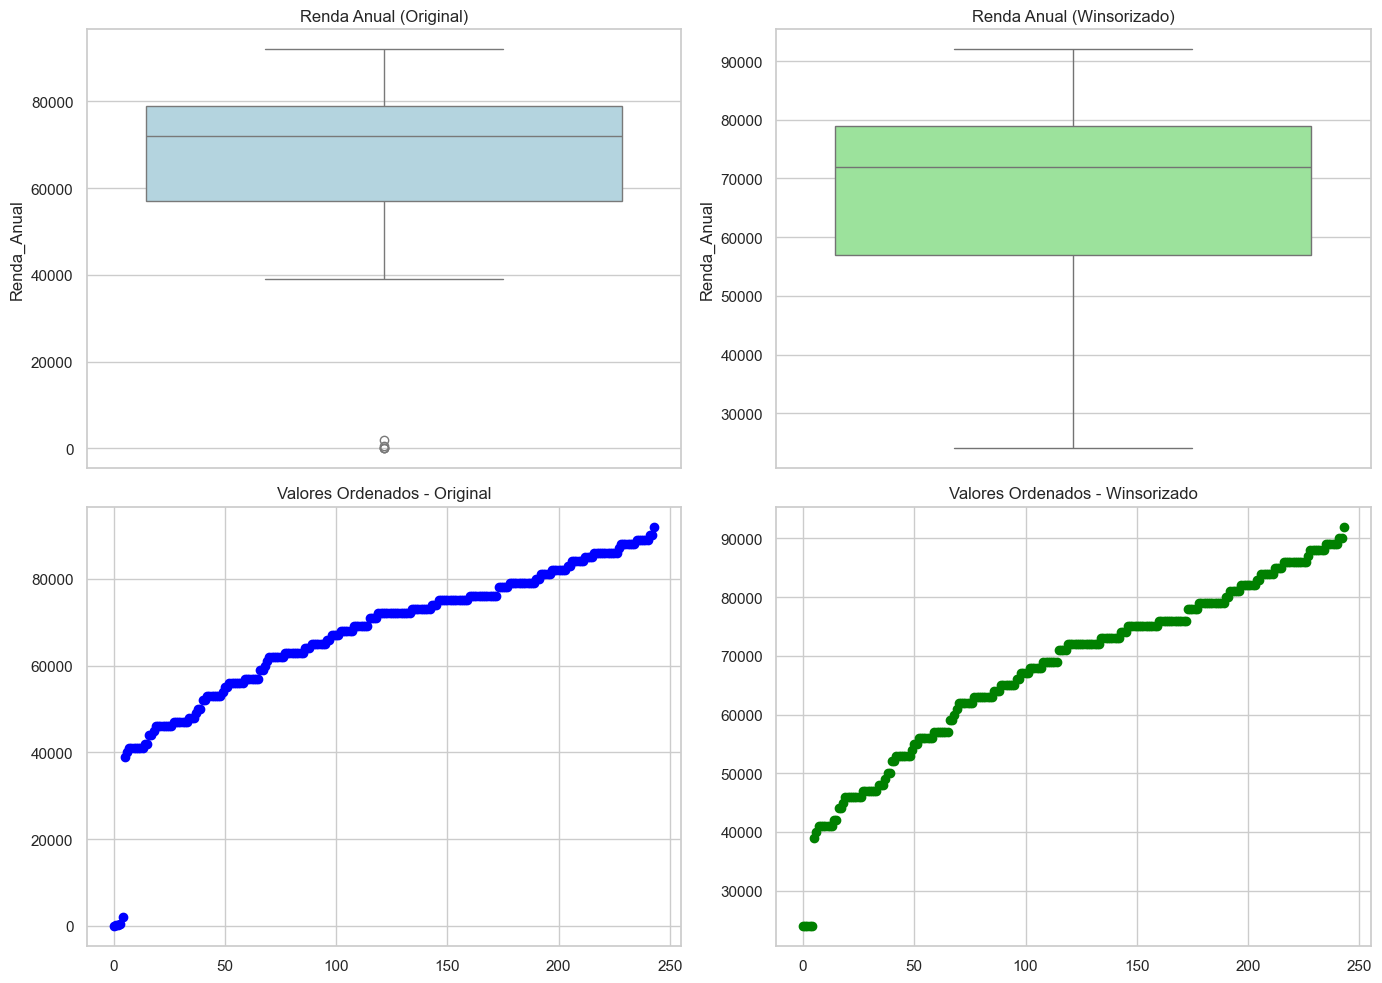

In [9]:
# Visualizações comparativas para Renda_Anual
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(y=renda_original, ax=axes[0, 0], color='lightblue')
axes[0, 0].set_title('Renda Anual (Original)')
sns.boxplot(y=df['Renda_Anual'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Renda Anual (Winsorizado)')
axes[1, 0].plot(np.sort(renda_original.dropna()), marker='o', linestyle='None', color='blue')
axes[1, 0].set_title('Valores Ordenados - Original')
axes[1, 1].plot(np.sort(df['Renda_Anual'].dropna()), marker='o', linestyle='None', color='green')
axes[1, 1].set_title('Valores Ordenados - Winsorizado')
plt.tight_layout()
plt.show()

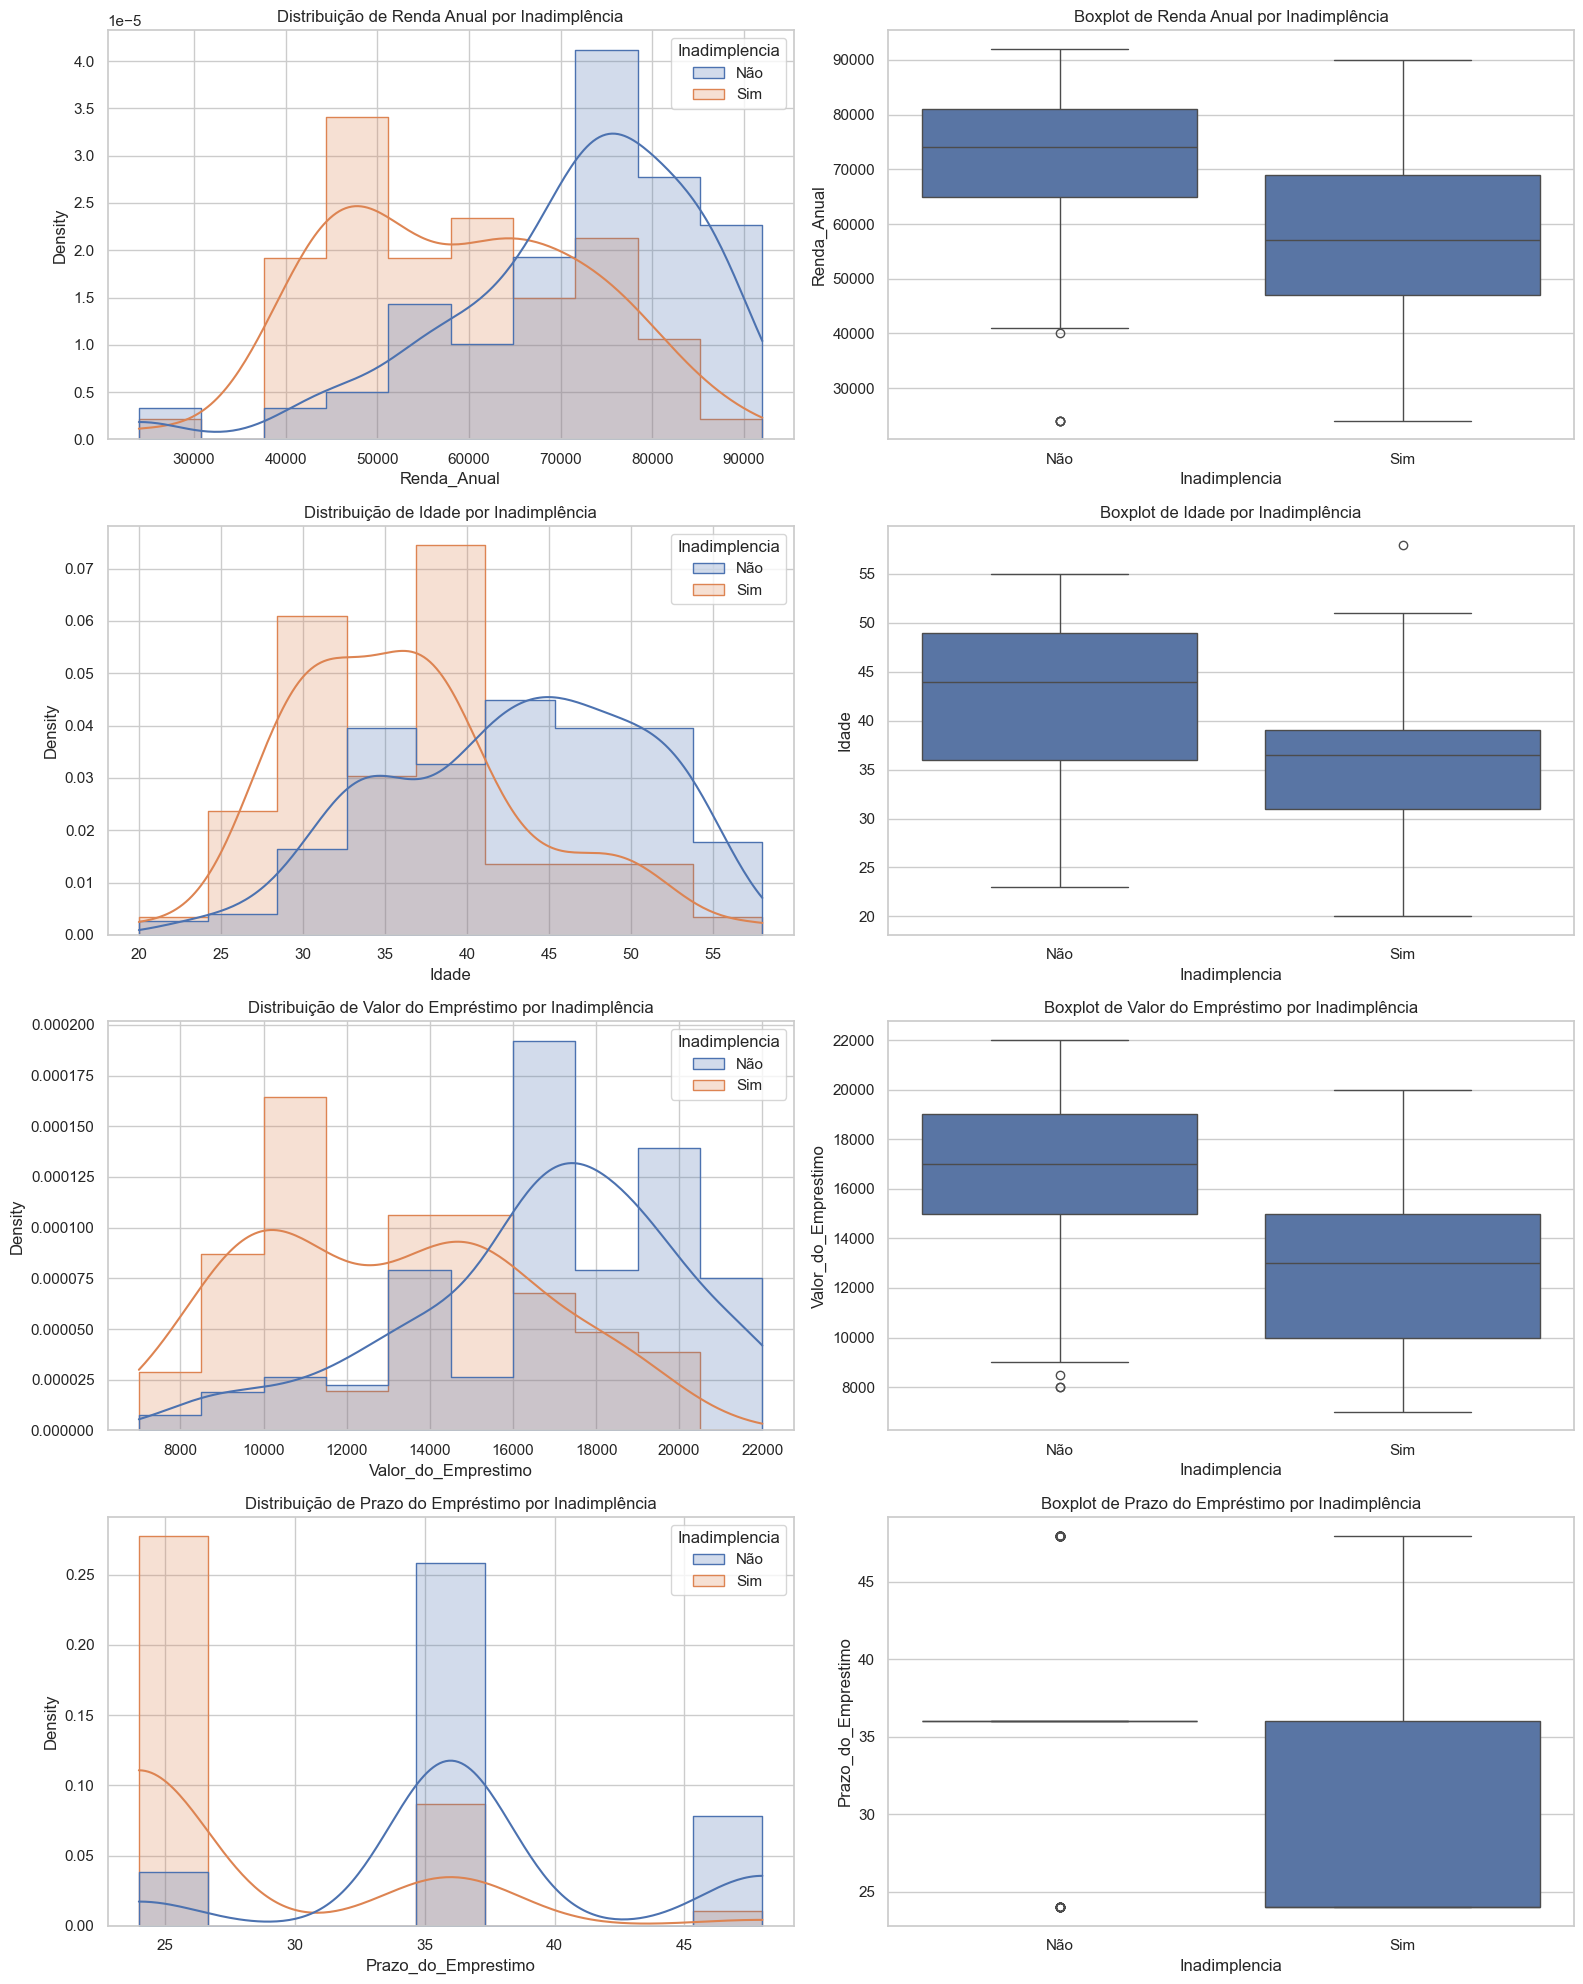

In [10]:
# Visualizações por variável e Inadimplência
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
sns.histplot(data=df, x='Renda_Anual', hue='Inadimplencia', kde=True,
             element="step", stat="density", common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title('Distribuição de Renda Anual por Inadimplência')
sns.boxplot(x='Inadimplencia', y='Renda_Anual', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot de Renda Anual por Inadimplência')
sns.histplot(data=df, x='Idade', hue='Inadimplencia', kde=True,
             element="step", stat="density", common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title('Distribuição de Idade por Inadimplência')
sns.boxplot(x='Inadimplencia', y='Idade', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Boxplot de Idade por Inadimplência')
sns.histplot(data=df, x='Valor_do_Emprestimo', hue='Inadimplencia', kde=True,
             element="step", stat="density", common_norm=False, ax=axes[2, 0])
axes[2, 0].set_title('Distribuição de Valor do Empréstimo por Inadimplência')
sns.boxplot(x='Inadimplencia', y='Valor_do_Emprestimo', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Boxplot de Valor do Empréstimo por Inadimplência')
sns.histplot(data=df, x='Prazo_do_Emprestimo', hue='Inadimplencia', kde=True,
             element="step", stat="density", common_norm=False, ax=axes[3, 0])
axes[3, 0].set_title('Distribuição de Prazo do Empréstimo por Inadimplência')
sns.boxplot(x='Inadimplencia', y='Prazo_do_Emprestimo', data=df, ax=axes[3, 1])
axes[3, 1].set_title('Boxplot de Prazo do Empréstimo por Inadimplência')
plt.tight_layout()
plt.show()

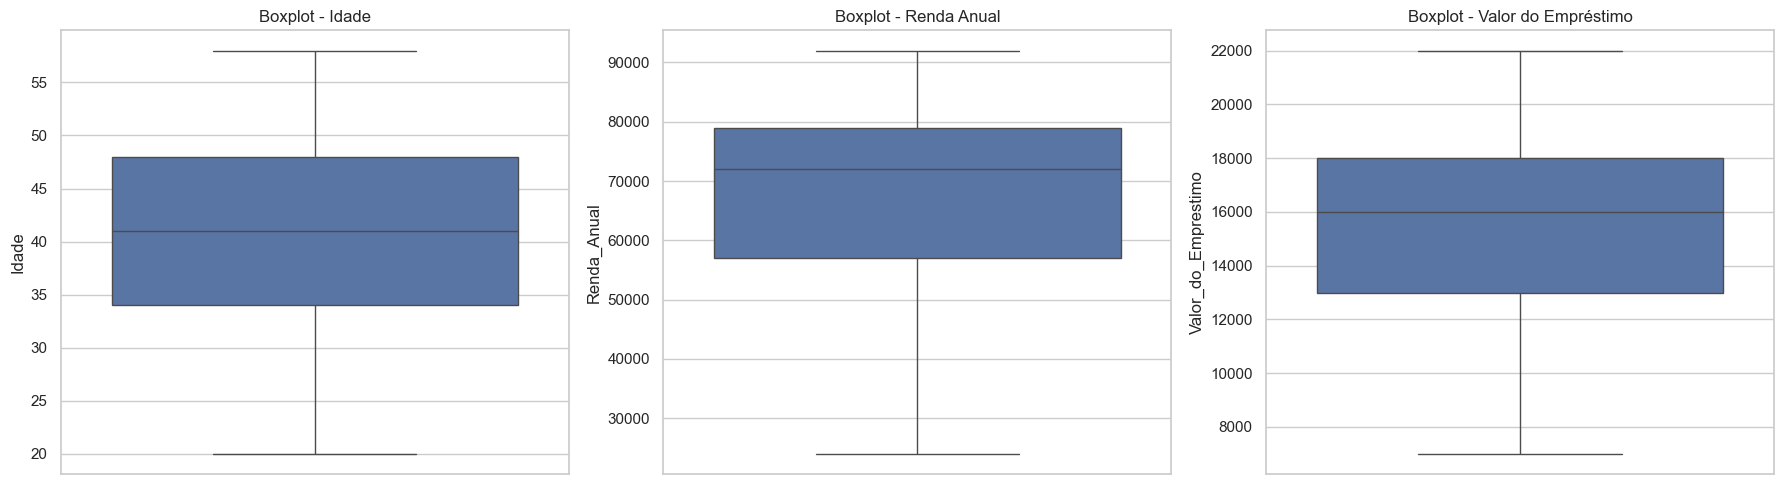

In [11]:
# Boxplots individuais para principais variáveis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df['Idade'], ax=axes[0])
axes[0].set_title('Boxplot - Idade')
sns.boxplot(y=df['Renda_Anual'], ax=axes[1])
axes[1].set_title('Boxplot - Renda Anual')
sns.boxplot(y=df['Valor_do_Emprestimo'], ax=axes[2])
axes[2].set_title('Boxplot - Valor do Empréstimo')
plt.tight_layout()
plt.show()

In [12]:
# Reordenar as colunas para deixar 'Inadimplencia' como a última coluna
cols = [col for col in df.columns if col != 'Inadimplencia'] + ['Inadimplencia']
df = df[cols]
df

,ID_Cliente,Idade,Genero,Estado_Civil,Escolaridade,Numero_de_Dependentes,Tipo_de_Residencia,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo,Inadimplencia
0,1,35,F,Casado,Ensino Superior,1,Casa Própria,60000.0,10000.0,36.0,Não
1,2,28,F,NaN,Ensino Médio,0,Casa Própria,40000.0,8000.0,24.0,Não
2,3,45,F,Casado,Pós-Graduação,2,Casa Alugada,24000.0,15000.0,48.0,Não
3,4,40,F,Divorciado,Ensino Superior,0,Casa Própria,NaN,12000.0,36.0,Não
4,5,33,F,Casado,Ensino Médio,1,Casa Alugada,50000.0,9000.0,24.0,Sim
...,...,...,...,...,...,...,...,...,...,...,...
245,246,51,M,Solteiro,Ensino Superior,2,Casa Própria,84000.0,18000.0,36.0,Não
246,247,46,F,Casado,Pós-Graduação,3,Apartamento Alugado,76000.0,19000.0,36.0,Não
247,248,41,F,Casado,Ensino Médio,1,Apartamento Alugado,69000.0,17000.0,36.0,Sim
248,249,36,F,Solteiro,Ensino Superior,0,Casa Alugada,62000.0,14000.0,24.0,Sim


# 2. Análise Exploratória (EDA) Detalhada
# 
 Nesta seção, além das visualizações já apresentadas, faremos:
 - Documentação do dicionário de dados (comentários sobre cada coluna)
 - Cálculo das estatísticas resumidas para variáveis numéricas (com `describe()`)
 - Análise do balanceamento da variável alvo (Inadimplencia)
 - Countplots para variáveis categóricas (ex.: Gênero, Estado_Civil)
 - Scatterplot de Renda_Anual vs Valor_do_Emprestimo colorido por Inadimplencia
 - Matriz de correlação (com heatmap)

In [13]:
# Dicionário de Dados (comentários/documentação – ajustado conforme conhecimento do negócio)
print("""
Dicionário de Dados:
- ID_Cliente: Identificador único do cliente.
- Idade: Idade do cliente (em anos). Valores fora de 18-100 foram removidos.
- Gênero: Masculino/Feminino.
- Estado_Civil: Ex: Solteiro, Casado, Divorciado, Viúvo.
- Escolaridade: Nível educacional (Fundamental, Médio, Superior, Pós-graduação).
- Renda_Anual: Renda anual do cliente (R$). Valores outliers foram winsorizados.
- Número_de_Dependentes: Número de dependentes.
- Tipo_de_Residência: Ex: Própria, Alugada, Financiada.
- Valor_do_Emprestimo: Valor do empréstimo solicitado (R$). Outliers controlados.
- Prazo_do_Emprestimo: Prazo do empréstimo (em meses).
- Inadimplencia: Target - 'Sim' ou 'Não'.
""")

# Estatísticas resumidas
print("Estatísticas resumidas (variáveis numéricas):")
print(df.describe())

# Balanceamento da variável alvo
print("Distribuição da variável Inadimplencia:")
print(df['Inadimplencia'].value_counts(normalize=True)*100)


Dicionário de Dados:
- ID_Cliente: Identificador único do cliente.
- Idade: Idade do cliente (em anos). Valores fora de 18-100 foram removidos.
- Gênero: Masculino/Feminino.
- Estado_Civil: Ex: Solteiro, Casado, Divorciado, Viúvo.
- Escolaridade: Nível educacional (Fundamental, Médio, Superior, Pós-graduação).
- Renda_Anual: Renda anual do cliente (R$). Valores outliers foram winsorizados.
- Número_de_Dependentes: Número de dependentes.
- Tipo_de_Residência: Ex: Própria, Alugada, Financiada.
- Valor_do_Emprestimo: Valor do empréstimo solicitado (R$). Outliers controlados.
- Prazo_do_Emprestimo: Prazo do empréstimo (em meses).
- Inadimplencia: Target - 'Sim' ou 'Não'.

Estatísticas resumidas (variáveis numéricas):
       ID_Cliente     Idade  Numero_de_Dependentes   Renda_Anual  \
count  250.000000     244.0             250.000000    244.000000   
mean   125.500000  41.07377               1.400000  67721.311475   
std     72.312977  8.111535               1.082908  14988.205127   
min 

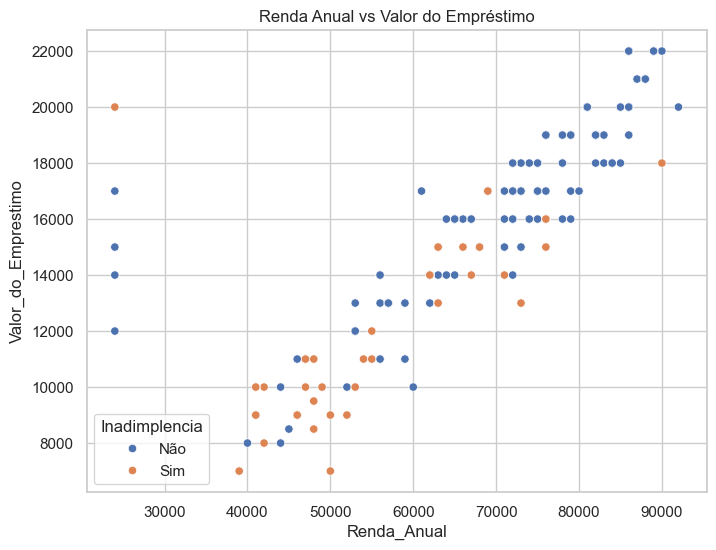

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Renda_Anual', y='Valor_do_Emprestimo', hue='Inadimplencia')
plt.title('Renda Anual vs Valor do Empréstimo')
plt.show()

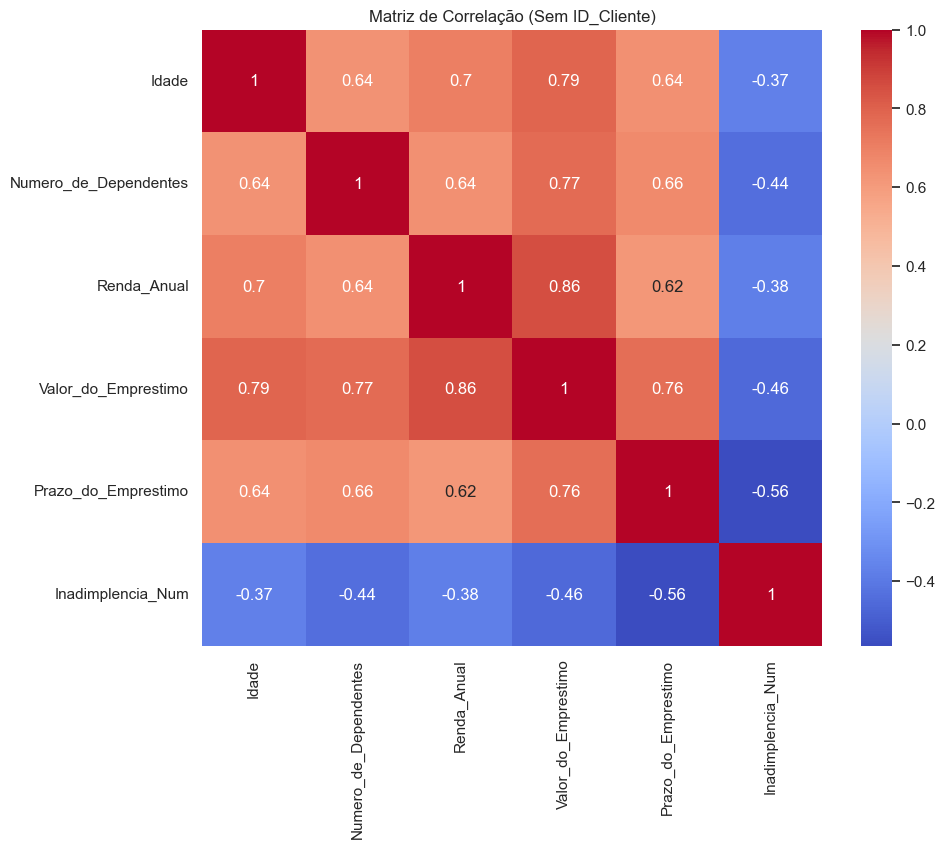

In [15]:
df_corr = df.copy()

# Converter Inadimplencia para 0/1
df_corr['Inadimplencia_Num'] = df_corr['Inadimplencia'].apply(lambda x: 1 if x=='Sim' else 0)

# Remover a coluna ID_Cliente antes de calcular a correlação
df_corr.drop(columns=['ID_Cliente'], inplace=True)

# Calcular a matriz de correlação apenas com colunas numéricas
corr_matrix = df_corr.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação (Sem ID_Cliente)')
plt.show()


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1) Copiar o DataFrame original
df_encoded_allcats = df.copy()

# 2) Remover ID_Cliente (se existir) e converter Inadimplencia em numérico
df_encoded_allcats.drop(columns=['ID_Cliente'], errors='ignore', inplace=True)
df_encoded_allcats['Inadimplencia_Num'] = df_encoded_allcats['Inadimplencia'].map({'Sim': 1, 'Não': 0})
df_encoded_allcats.drop(columns=['Inadimplencia'], inplace=True)

# 3) Identificar colunas categóricas e criar dummies
cat_cols = df_encoded_allcats.select_dtypes(include=['object']).columns
df_encoded_allcats = pd.get_dummies(df_encoded_allcats, columns=cat_cols, drop_first=False)

print(df_encoded_allcats.columns)



Index(['Idade', 'Numero_de_Dependentes', 'Renda_Anual', 'Valor_do_Emprestimo',
       'Prazo_do_Emprestimo', 'Inadimplencia_Num', 'Genero_F', 'Genero_M',
       'Estado_Civil_Casado', 'Estado_Civil_Divorciado',
       'Estado_Civil_Solteiro', 'Escolaridade_Ensino Médio',
       'Escolaridade_Ensino Superior', 'Escolaridade_Pós-Graduação',
       'Tipo_de_Residencia_Apartamento Alugado',
       'Tipo_de_Residencia_Apartamento Próprio',
       'Tipo_de_Residencia_Casa Alugada', 'Tipo_de_Residencia_Casa Própria'],
      dtype='object')


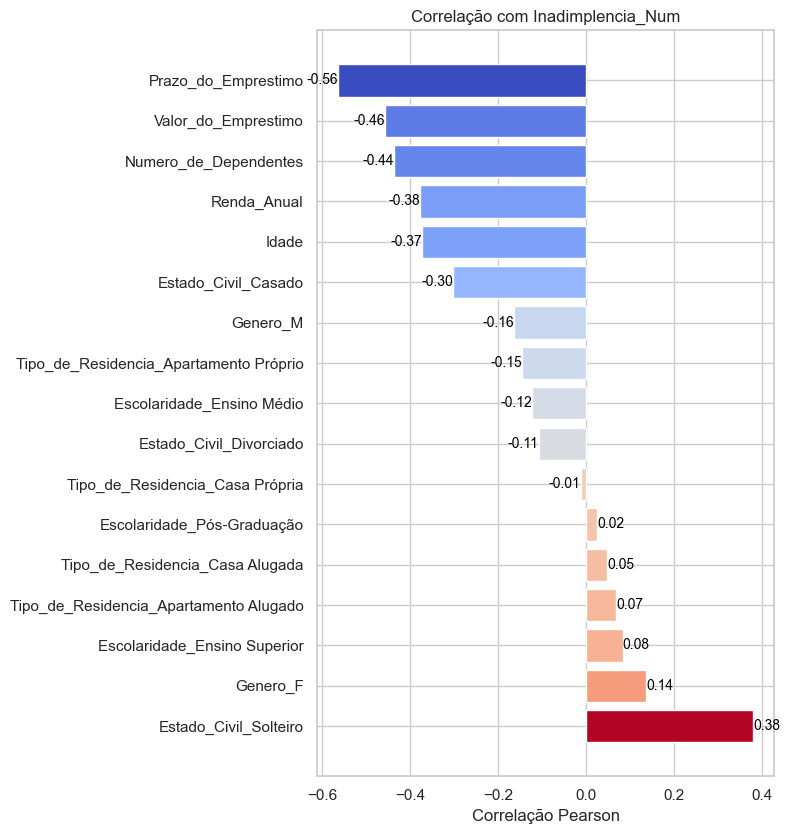

In [17]:
corr_matrix_allcats = df_encoded_allcats.corr(method='pearson')

# Extrair as correlações com a coluna Inadimplencia_Num, exceto ela mesma
corr_with_inad_allcats = corr_matrix_allcats['Inadimplencia_Num'].drop('Inadimplencia_Num')
corr_with_inad_allcats = corr_with_inad_allcats.sort_values(ascending=False)

# Plotar em barras horizontais, colorindo tipo "heatmap"
fig, ax = plt.subplots(figsize=(8, len(corr_with_inad_allcats)*0.5))

cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=corr_with_inad_allcats.min(), 
                           vmax=corr_with_inad_allcats.max())

bars = ax.barh(
    corr_with_inad_allcats.index, 
    corr_with_inad_allcats.values, 
    color=[cmap(norm(val)) for val in corr_with_inad_allcats.values]
)

# Adicionar o valor da correlação em cada barra
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'{width:.2f}', 
            ha='left' if width >= 0 else 'right',
            va='center', color='black', fontsize=10)

ax.set_xlabel('Correlação Pearson')
ax.set_title('Correlação com Inadimplencia_Num')
plt.tight_layout()
plt.show()


 ## 3. Modelagem Preditiva com PyCaret - Comparação de Múltiplos Modelos

Nesta etapa, vamos treinar e comparar individualmente os seguintes modelos:

- **Modelos Clássicos:** Regressão Logística (`lr`), Árvore de Decisão (`dt`), Random Forest (`rf`)
- **Modelos de Boosting:** XGBoost (`xgboost`), LightGBM (`lightgbm`), CatBoost (`catboost`)
- **Rede Neural (MLP):** `mlp`
 
 Para cada modelo, criamos, afinamos, finalizamos e geramos a avaliação (curva ROC e matriz de confusão).

In [18]:
from pycaret.classification import setup, create_model, tune_model, finalize_model, predict_model
from tqdm.notebook import tqdm

# Configuração aprimorada do ambiente do PyCaret
exp_setup = setup(data=df, 
                  target='Inadimplencia', 
                  session_id=42, 
                  normalize=True, 
                  fix_imbalance=True, 
                  train_size=0.8,  # Com poucos dados, 80% para treino pode ajudar na aprendizagem
                  fold=10,         # 10-fold cross-validation para métricas mais estáveis
                  data_split_stratify=True,
                  ignore_features=['ID_Cliente'],  # Ignorar a coluna identificadora
                  categorical_features=['Genero', 'Estado_Civil', 'Escolaridade', 'Tipo_de_Residencia'],
                  verbose=True)

# Definir os modelos e seus respectivos identificadores
model_ids = ['lr', 'dt', 'rf', 'xgboost', 'lightgbm', 'catboost', 'mlp']
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest',
               'XGBoost', 'LightGBM', 'CatBoost', 'MLP']

# Dicionário para armazenar os modelos finalizados e suas predições
models_dict = {}
predictions_dict = {}

print("Treinando e avaliando os modelos:")

for mid, name in tqdm(list(zip(model_ids, model_names)), total=len(model_ids), desc="Modelos"):
    print("\n==============================")
    print("Treinando modelo:", name)
    
    # Criar o modelo
    model = create_model(mid)
    print("Modelo criado.")
    
    # Afinar o modelo
    tuned = tune_model(model)
    print("Modelo afinado.")
    
    # Finalizar o modelo (treinamento com todos os dados de treino)
    final = finalize_model(tuned)
    print("Modelo finalizado.")
    
    # Armazenar o modelo finalizado
    models_dict[name] = final
    
    # Avaliar o modelo no conjunto de holdout
    pred_holdout = predict_model(final)
    predictions_dict[name] = pred_holdout
    
    print("Previsões (head) para", name)
    display(pred_holdout.head())
    
print("\nTodos os modelos foram treinados e avaliados.")


,Description,Value
0,Session id,42
1,Target,Inadimplencia
2,Target type,Binary
3,Target mapping,"Não: 0, Sim: 1"
4,Original data shape,"(250, 11)"
5,Transformed data shape,"(338, 17)"
6,Transformed train set shape,"(288, 17)"
7,Transformed test set shape,"(50, 17)"
8,Ignore features,1
9,Numeric features,5


Treinando e avaliando os modelos:


Modelos:   0%|          | 0/7 [00:00<?, ?it/s]


Treinando modelo: Logistic Regression


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7000,0.6667,0.7000,0.7418,0.7143,0.2941,0.3026
1,0.7000,0.7067,0.7000,0.7418,0.7143,0.2941,0.3026
2,0.6500,0.4800,0.6500,0.6726,0.6599,0.1250,0.1260
3,0.8500,0.8400,0.8500,0.8631,0.8542,0.6250,0.6299
4,0.8500,0.9048,0.8500,0.8467,0.8458,0.6250,0.6299
5,0.8500,0.9167,0.8500,0.8467,0.8458,0.6250,0.6299
6,0.9000,0.9762,0.9000,0.9000,0.9000,0.7619,0.7619
7,0.8500,0.8214,0.8500,0.9000,0.8560,0.6875,0.7237
8,0.7500,0.8810,0.7500,0.8030,0.7600,0.4792,0.5044


...

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Modelo afinado.
Modelo finalizado.


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,MLP Classifier,0.9000,0.8611,0.9000,0.8985,0.8988,0.7465,0.7474


Previsões (head) para MLP


,Idade,Genero,Estado_Civil,Escolaridade,Numero_de_Dependentes,Tipo_de_Residencia,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo,Inadimplencia,prediction_label,prediction_score
178,33,F,Solteiro,Ensino Médio,0,Casa Própria,56000.0,14000.0,36.0,Não,Não,0.5577
206,28,F,Solteiro,Ensino Superior,0,Casa Própria,41000.0,10000.0,24.0,Sim,Sim,0.9507
71,49,F,Solteiro,Pós-Graduação,2,Apartamento Alugado,80000.0,17000.0,36.0,Não,Não,0.5696
152,28,F,Solteiro,Ensino Superior,0,Casa Própria,41000.0,10000.0,24.0,Sim,Sim,0.9507
148,48,F,Casado,Pós-Graduação,3,Casa Própria,79000.0,19000.0,36.0,Não,Não,0.6936



Todos os modelos foram treinados e avaliados.


## 5. Avaliação dos Modelos
 
 Nesta etapa, vamos consolidar e visualizar as métricas dos modelos e, em seguida,
 gerar gráficos de desempenho para o modelo final selecionado. 
 O código a seguir extrai as métricas do PyCaret e plota a curva ROC e a matriz de confusão do último modelo treinado.

In [19]:
from pycaret.classification import get_config
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score
import pandas as pd

# Obter os dados de teste do PyCaret
X_test = get_config('X_test')
y_test = get_config('y_test')
# Mapear o target para binário: 'Não' -> 0, 'Sim' -> 1
y_test_bin = y_test.map({'Não': 0, 'Sim': 1})

metrics_list = []

for model_name, model in models_dict.items():
    pred_df = predict_model(model, data=X_test)
    # Usar a coluna 'prediction_score' como a probabilidade da classe positiva
    y_pred_prob = pred_df['prediction_score']
    # Usar a coluna 'prediction_label' e mapear para binário
    y_pred = pred_df['prediction_label'].map({'Não': 0, 'Sim': 1})
    
    acc = accuracy_score(y_test_bin, y_pred)
    auc = roc_auc_score(y_test_bin, y_pred_prob)
    rec = recall_score(y_test_bin, y_pred)
    prec = precision_score(y_test_bin, y_pred)
    f1 = f1_score(y_test_bin, y_pred)
    
    metrics_list.append({
        'Modelo': model_name,
        'Accuracy': acc,
        'AUC': auc,
        'Recall': rec,
        'Precision': prec,
        'F1': f1
    })

metrics_df = pd.DataFrame(metrics_list)
display(metrics_df)


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


,Modelo,Accuracy,AUC,Recall,Precision,F1
0,Logistic Regression,0.88,0.583333,0.785714,0.785714,0.785714
1,Decision Tree,0.90,0.865079,0.785714,0.846154,0.814815
2,Random Forest,0.90,0.865079,0.785714,0.846154,0.814815
3,XGBoost,0.94,0.344246,0.857143,0.923077,0.888889
4,LightGBM,0.90,0.798611,0.785714,0.846154,0.814815
5,CatBoost,0.94,0.361111,0.857143,0.923077,0.888889
6,MLP,0.90,0.575397,0.785714,0.846154,0.814815


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


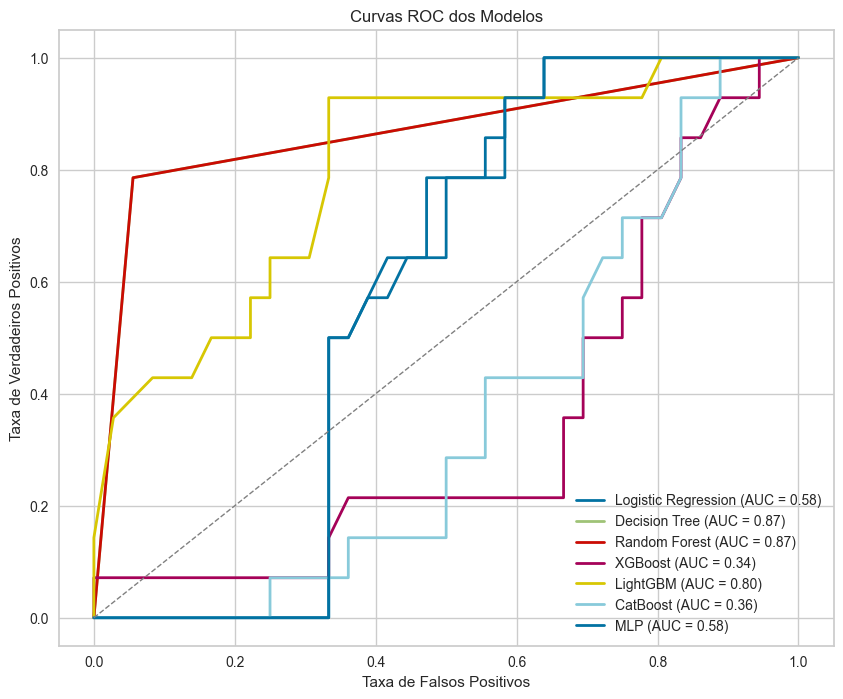

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

for model_name, model in models_dict.items():
    pred_df = predict_model(model, data=X_test)
    y_pred_prob = pred_df['prediction_score']
    fpr, tpr, _ = roc_curve(y_test_bin, y_pred_prob)
    auc_val = roc_auc_score(y_test_bin, y_pred_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {auc_val:.2f})")

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC dos Modelos')
plt.legend(loc="lower right")
plt.show()


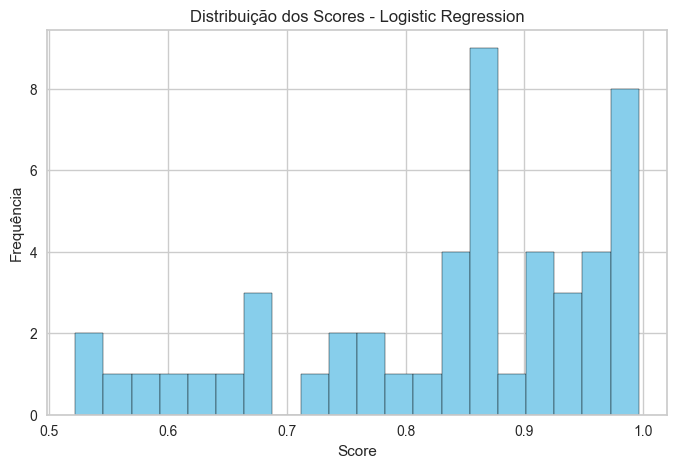

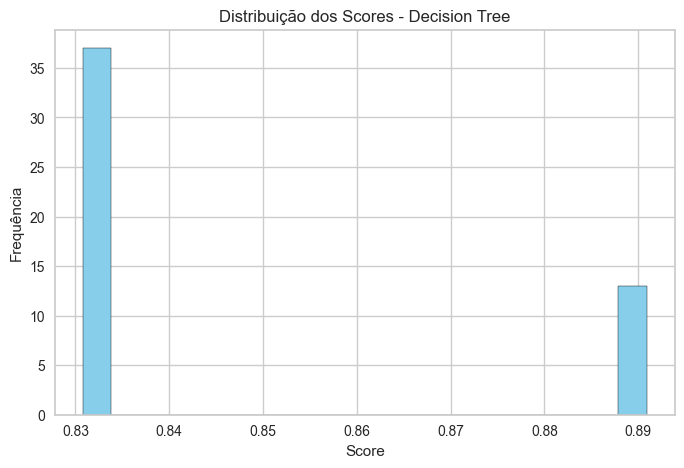

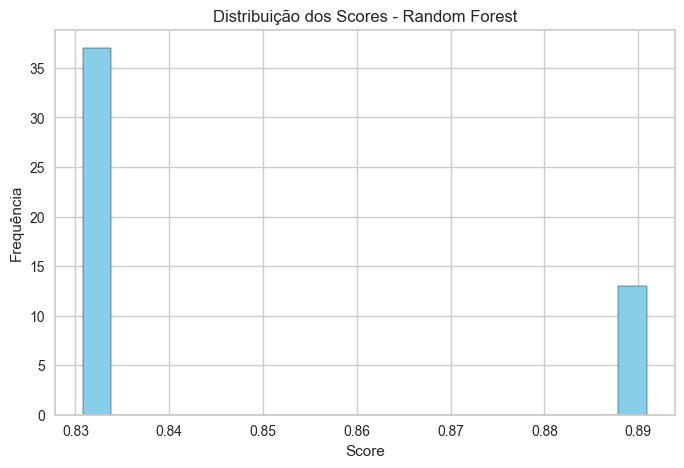

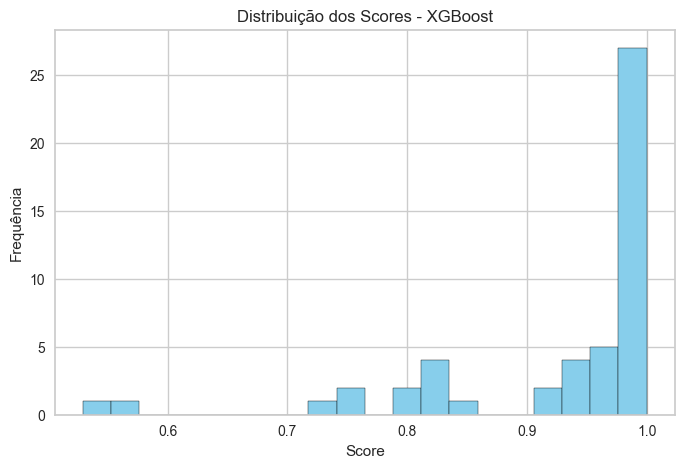

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


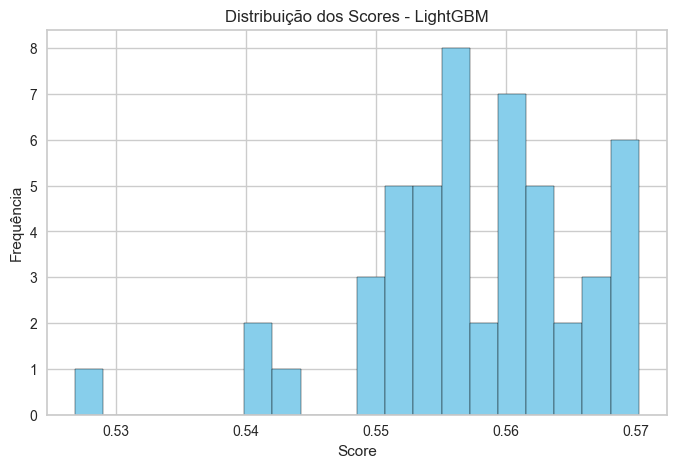

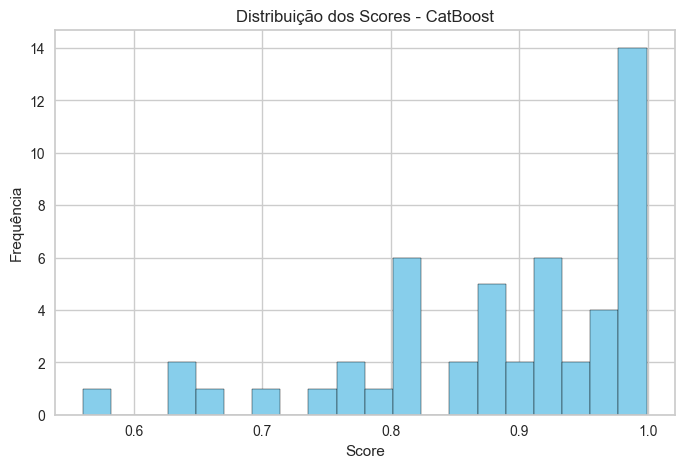

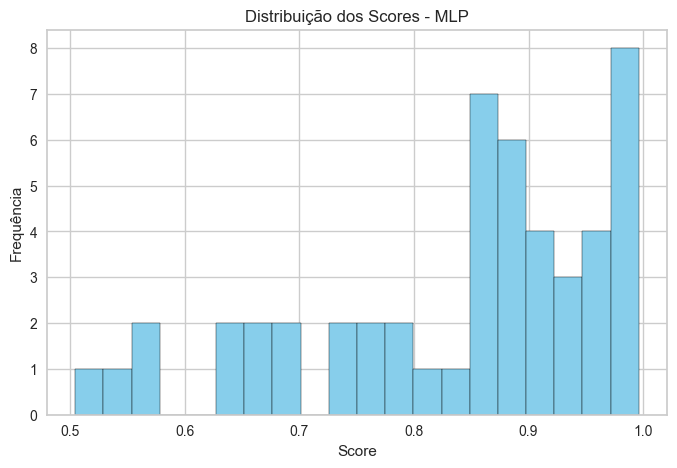

In [21]:
import matplotlib.pyplot as plt

for model_name, model in models_dict.items():
    pred_df = predict_model(model, data=X_test)
    plt.figure(figsize=(8, 5))
    plt.hist(pred_df['prediction_score'], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Distribuição dos Scores - {model_name}")
    plt.xlabel("Score")
    plt.ylabel("Frequência")
    plt.show()


In [22]:
from pycaret.classification import get_config
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

# Selecionar o modelo Random Forest (ou outro que se deseja calibrar)
rf_model = models_dict['Random Forest']

# Obter dados de treino do PyCaret
X_train = get_config('X_train')
y_train = get_config('y_train').map({'Não': 0, 'Sim': 1})

# Calibrar o modelo com isotonic regression usando 10-fold CV
calibrated_rf = CalibratedClassifierCV(base_estimator=rf_model, method='isotonic', cv=10)
calibrated_rf.fit(X_train, y_train)

# Obter dados de teste e prever probabilidades com o modelo calibrado
X_test = get_config('X_test')
y_test = get_config('y_test').map({'Não': 0, 'Sim': 1})
y_calibrated_proba = calibrated_rf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8,6))
plt.hist(y_calibrated_proba, bins=20, color='lightgreen', edgecolor='black')
plt.title("Distribuição dos Scores Calibrados - Random Forest")
plt.xlabel("Score")
plt.ylabel("Frequência")
plt.show()


TypeError: CalibratedClassifierCV.__init__() got an unexpected keyword argument 'base_estimator'

In [ ]:
from pycaret.classification import blend_models, predict_model, plot_model

# Selecionar os modelos que deseja empilhar; ajuste conforme os resultados da sua tabela
model_list = [models_dict['Random Forest'], models_dict['XGBoost'], models_dict['CatBoost']]
stacked_model = blend_models(estimator_list=model_list, fold=10)
print("Modelo de ensemble (stacking) criado.")

# Avaliar o modelo empilhado no conjunto de teste
pred_stacked = predict_model(stacked_model)
display(pred_stacked.head())

# Plotar curva ROC e matriz de confusão do modelo empilhado em blocos separados
print("Curva ROC para o modelo empilhado:")
plot_model(stacked_model, plot='auc')

print("Matriz de Confusão para o modelo empilhado:")
plot_model(stacked_model, plot='confusion_matrix')
